In [9]:
import os
import warnings
from transformers import logging

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
logging.set_verbosity_error()


In [10]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd

# charts
import matplotlib.pyplot as plt
import seaborn as sns


# Pretreained HerBERT
from transformers import pipeline
import torch
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

print(f"Text : {dataset[0]['sentence']}")
print(f"Label : {dataset[0]['target']}")

Text : Leczyła m się u niej parę lat i nic mi nie pomogła , a jak zmieniła m lekarza po krótkim czasie zobaczyła m już poprawę a w tej chwili jestem już bez leków 6 lat i jest wszystko dobrze . Dr Ciborska leczyła mnie na depresję a potem przez dr Kopystecką miała m rozpoznany zespół maniakalno depresyjny i odtąd zmianę leków i przede wszystkim wysłuchała mnie z zaagażowaniem a nie jak dr Ciborska aby mnie zbyć
Label : __label__meta_minus_m


In [12]:
df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

In [13]:


summary_table = df.groupby('target')['text_length'].agg(
    probes='count',
    min_length='min',
    max_length='max',
    avg_length='mean',
    median_length='median'
).round(2)

total_stats = {
    'probes': df['text_length'].count(),
    'min_length': df['text_length'].min(),
    'max_length': df['text_length'].max(),
    'avg_length': df['text_length'].mean(),
    'median_length': df['text_length'].median()
}

summary_table.loc['Total'] = total_stats

summary_table = summary_table.round(2)
summary_table['probes'] = summary_table['probes'].astype(int)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print(summary_table)

          probes  min_length  max_length  avg_length  median_length
target                                                             
Negative     300         189        2469      778.98          648.0
Neutral      117          29        1605      854.68          852.0
Positive     197         243        2350      672.97          599.0
Total        614          29        2469      759.39          694.0


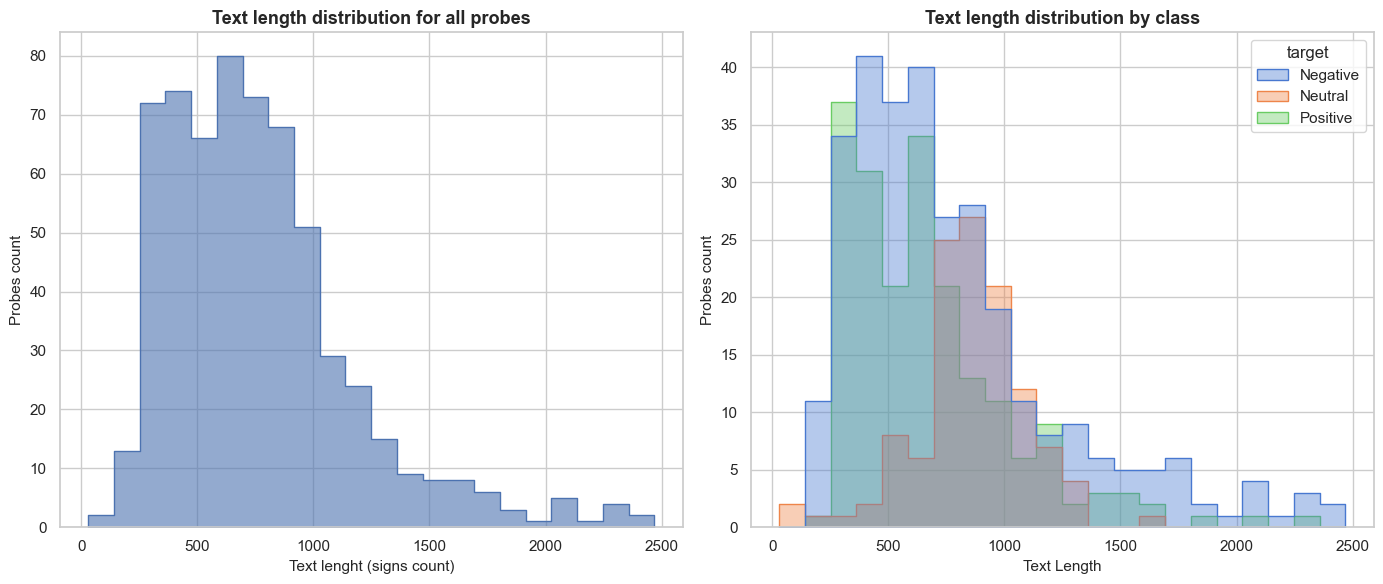

In [14]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

sns.histplot(
    data=df,
    x='text_length',
    ax=axes[0],
    element='step',
    alpha=0.6
)
axes[0].set_title('Text length distribution for all probes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Text lenght (signs count)', fontsize=11)
axes[0].set_ylabel('Probes count', fontsize=11)

sns.histplot(
    data=df,
    x='text_length',
    hue='target',
    ax=axes[1],
    element='step',
    stat='count',
    common_norm=False,
    palette='muted',
    alpha=0.4
)
axes[1].set_title('Text length distribution by class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Text Length', fontsize=11)
axes[1].set_ylabel('Probes count', fontsize=11)

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

In [ ]:
reviews_texts = df['sentence'].tolist()

model_label_mapping = {
    'neutral': 'Neutral',
    'negative': 'Negative',
    'positive': 'Positive'
}

classifier = pipeline(
    "text-classification",
    model="Voicelab/herbert-base-cased-sentiment",
    device="cuda"
)

sentences = df['sentence'].tolist()


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8278.48it/s]


Starting classification using HerBERT...

===== Classification report =====
              precision    recall  f1-score   support

       Minus       0.00      0.00      0.00         0
    Negative       0.00      0.00      0.00       300
     Neutral       0.34      0.14      0.20       117
        Plus       0.00      0.00      0.00         0
    Positive       0.00      0.00      0.00       197

    accuracy                           0.03       614
   macro avg       0.07      0.03      0.04       614
weighted avg       0.06      0.03      0.04       614




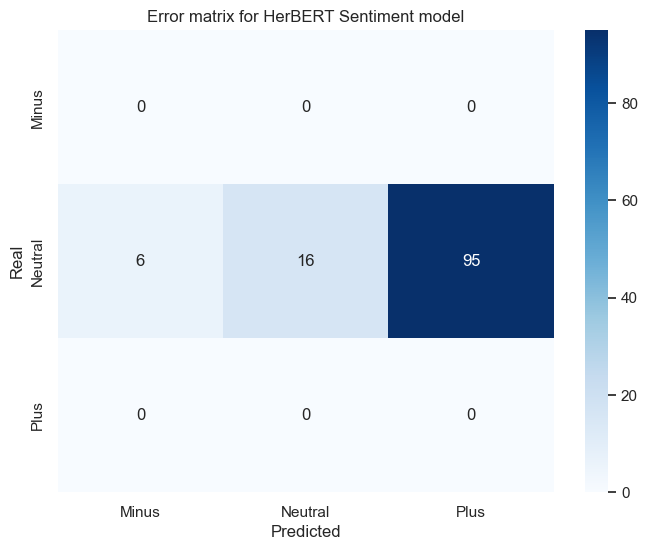

In [ ]:
print("Starting classification using HerBERT...")

predictions = classifier(sentences, batch_size=32, truncation=True, max_length=512, stride=64)

predicted_labels_raw = [pred['label'] for pred in predictions]

model_label_mapping = {
    'neutral': 'Neutral',
    'negative': 'Negative',
    'positive': 'Positive'
}

df['predicted_target'] = [model_label_mapping.get(lbl, lbl) for lbl in predicted_labels_raw]

print("\n===== Classification report =====")
print(classification_report(df['target'], df['predicted_target']))
print()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(df['target'], df['predicted_target'], labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.title('Error matrix for HerBERT Sentiment model')
plt.show()